 ### Loading the synthetic data 


In [1]:
using JLD2
@load "synthetic_data/noise_0_hh_2d_model.jld"

3-element Vector{Symbol}:
 :t
 :V
 :n

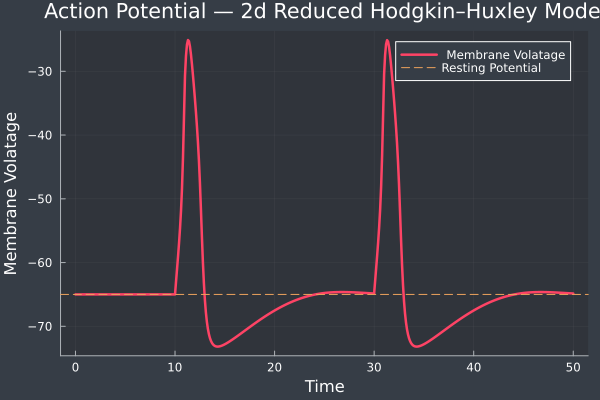

In [2]:
using Plots
theme(:dark)
plot(t,V, xlabel="Time" , ylabel="Membrane Volatage",linewidth = 2.5 ,title = "Action Potential — 2d Reduced Hodgkin–Huxley Model" ,label = " Membrane Volatage")
hline!([-65], linestyle=:dash ,    label = "Resting Potential")

In [3]:

# A gaussian noise is  add
# GAUSSIAN NOISE are unbiased , realistic and statistically justified noise that contians the many samll random affects added up to gather
# Noise in neuronal dynamics represents unresolved microscopic processes and measurement uncertainty 
#that collectively perturb the membrane voltage.

    using Statistics , Random

    function add_noise(t,V,strength)

        σ_V = std(V)
        
        σ_V_strength = strength * σ_V
    



        # Generating the gaussian noise
        noised_V  = randn(length(V)).*  σ_V_strength
        

        return V .+ noised_V 



        
    end

add_noise (generic function with 1 method)

In [4]:
    Random.seed!(1234)

    V_05  = add_noise(t,V,0.05)
    V_20  = add_noise(t,V,0.20)


    # @save "synthetic_data/noise_5_hh_2d_model.jld" t , V=V_05 , 


501-element Vector{Float64}:
 -67.26136258742363
 -67.46151445863518
 -63.91960682511311
 -62.812995789982814
 -67.4359306200809
 -66.26380370844907
 -63.00336750916778
 -61.01044480368924
 -64.03869407034607
 -66.34373225960513
   ⋮
 -64.23356666668649
 -63.91035154765574
 -65.17543489672032
 -64.4883839718528
 -61.70946522664997
 -64.04459038047547
 -64.16333765172803
 -65.9083912648891
 -63.391948209203655

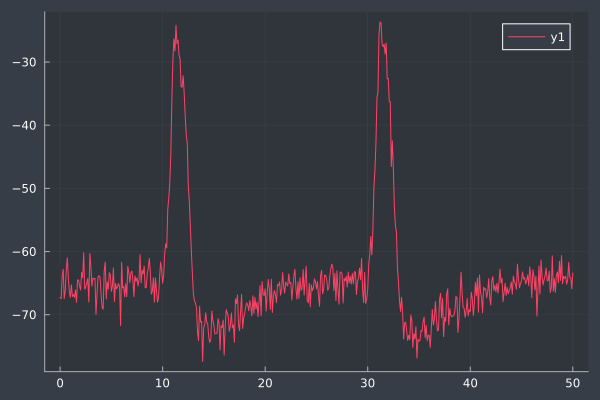

In [5]:
plot(t,V_20)

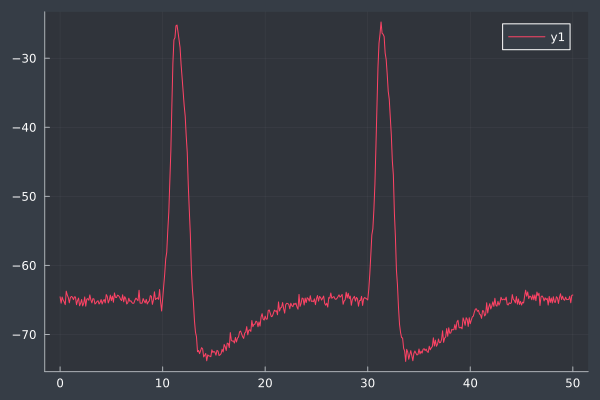

In [6]:
plot(t,V_05)

In [7]:
# Lets Save the data

@save  "synthetic_data/noise_05_hh_2d_model.jld" t=t , V =V_05
@save  "synthetic_data/noise_20_hh_2d_model.jld" t=t , V = V_20

# Loding the experimental data

In [1]:
# load the data

In [2]:
df

UndefVarError: UndefVarError: `df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [3]:
println("human_neuron_data = $(size(df))")
println("maximum =  $(maximum(df.Input_Current_pA))")
println("minimum =  $(minimum(df.Input_Current_pA))")
println("std =  $(std(df.Input_Current_pA))")
println("mean =  $(mean(df.Input_Current_pA))")

println("-------------------")


println("mouse_neuron_data = $(size(df2))")
println("maximum =  $(maximum(df2.current_pa))")
println("minimum =  $(minimum(df2.current_pa))")
println("std =  $(std(df2.current_pa))")
println("mean =  $(mean(df2.current_pa))")


UndefVarError: UndefVarError: `df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Lets Plot and see the graphs

In [4]:
# df ---> human neuron
# df2---> mouse neuron
plot(df2.time_ms,df2.voltage_mv)    

UndefVarError: UndefVarError: `plot` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [5]:
plot(df2.time_ms , df2.current_pa)

UndefVarError: UndefVarError: `plot` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [6]:
plot(df.Time_ms , df.Membrane_Voltage_mV)

UndefVarError: UndefVarError: `plot` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [7]:
plot(df.Time_ms , df.Input_Current_pA	)

UndefVarError: UndefVarError: `plot` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [8]:
# ...existing code...
startindex = max(1, firstspike - 10000)
endindex = min(length(df2.voltage_mv), firstspike + 10000)
start_time = df2.time_ms[startindex]
end_time = df2.time_ms[endindex]
# ...existing code...

UndefVarError: UndefVarError: `firstspike` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [9]:
plot(df2.time_ms[startindex:endindex], df2.voltage_mv[startindex:endindex],
    xlabel="Time (ms)", ylabel="Membrane Voltage (mV)",
    title="Mouse Neuron Voltage around First Spike",
    label="Membrane Voltage")

UndefVarError: UndefVarError: `df2` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [10]:
p1 = plot(df2.time_ms[startindex:endindex], df2.voltage_mv[startindex:endindex],
    xlabel="Time (ms)", ylabel="Membrane Voltage (mV)",
    title="Mouse Neuron Voltage and Current around First Spike",
    label="Membrane Voltage", legend=:topright)

p2 = plot(df2.time_ms[startindex:endindex], df2.current_pa[startindex:endindex],
    xlabel="Time (ms)", ylabel="Input Current (pA)",
    label="Input Current", legend=:topright)

plot(p1, p2, layout=(2, 1), size=(800, 600))

UndefVarError: UndefVarError: `df2` not defined in `Main`
Suggestion: check for spelling errors or missing imports.